# Cognifyz Data Analysis Internship

## Level 1 - Task 2

### Task:
Identify the city with the highest number of restaurants.
Calculate the average rating for restaurants in each city.
Determine the city with the highest average rating.

**Name:** Suraj 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset .csv")

In [3]:
df.shape

(9551, 21)

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
city_count = df["City"].value_counts()

city_count.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64

In [6]:
print("City with Highest Number of Restaurants:")
print(city_count.idxmax())
print("Total Restaurants:", city_count.max())

City with Highest Number of Restaurants:
New Delhi
Total Restaurants: 5473


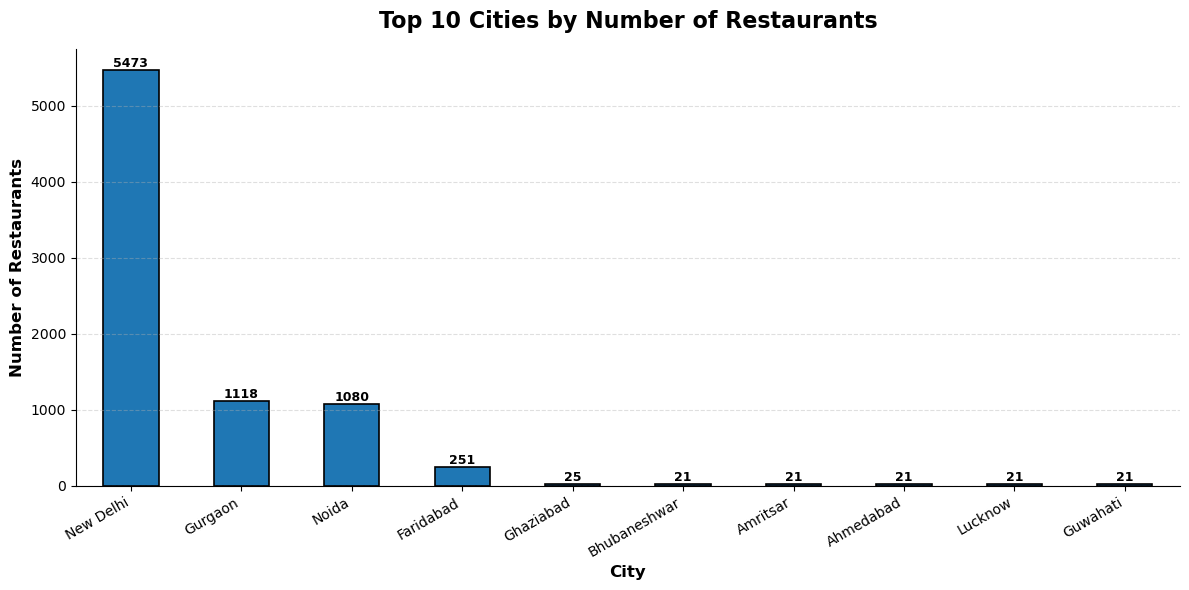

In [7]:
# Professional Bar Chart - Top 10 Cities by Number of Restaurants

top10_cities = city_count.head(10)

plt.figure(figsize=(12,6))

ax = top10_cities.plot(
    kind="bar",
    color="#1f77b4",
    edgecolor="black",
    linewidth=1.2
)

# Title
plt.title(
    "Top 10 Cities by Number of Restaurants",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel("City", fontsize=12, fontweight="bold")
plt.ylabel("Number of Restaurants", fontsize=12, fontweight="bold")

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Remove Top & Right Border
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Rotate X-axis Labels
plt.xticks(rotation=30, ha="right")

# Data Labels
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [8]:
city_summary = df.groupby("City").agg(
    Total_Restaurants=("Restaurant ID", "count"),
    Average_Rating=("Aggregate rating", "mean")
)

city_summary.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,Total_Restaurants,Average_Rating
City,,
Inner City,2,4.900000
Quezon City,1,4.800000
Makati City,2,4.650000
Pasig City,3,4.633333
Mandaluyong City,4,4.625000
Beechworth,1,4.600000
London,20,4.535000
Taguig City,4,4.525000
Tagaytay City,1,4.500000


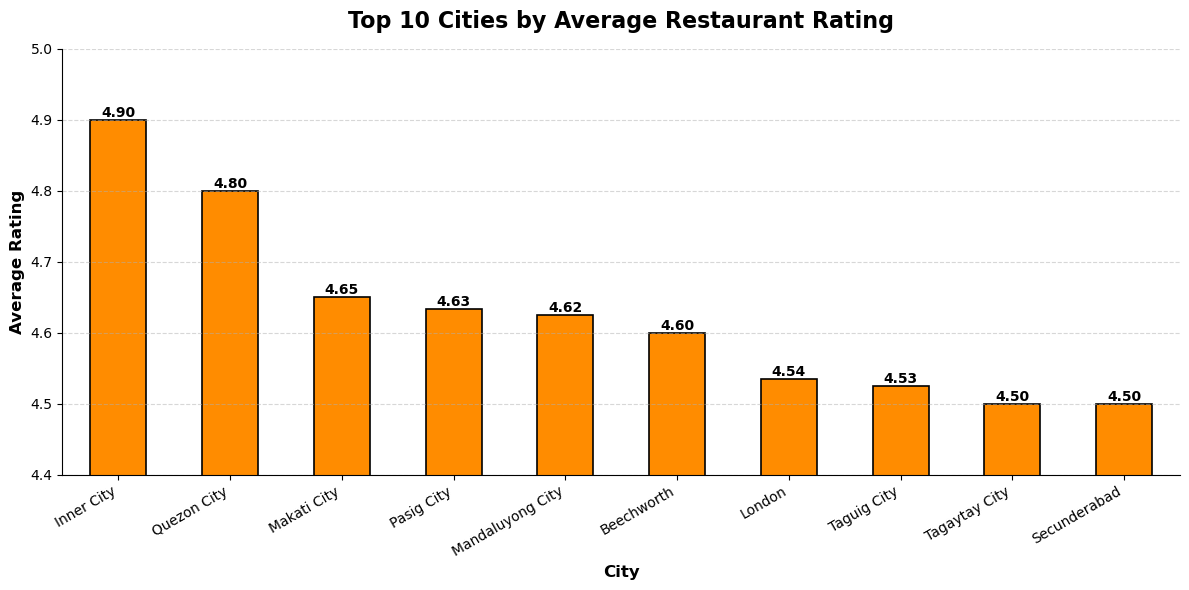

In [9]:
# Top 10 Cities by Average Rating 

top10_rating = city_summary["Average_Rating"].sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

ax = top10_rating.plot(
    kind="bar",
    color="#FF8C00",      # Dark Orange
    edgecolor="black",
    linewidth=1.2
)

# Title
plt.title(
    "Top 10 Cities by Average Restaurant Rating",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel("City", fontsize=12, fontweight="bold")
plt.ylabel("Average Rating", fontsize=12, fontweight="bold")

# X-axis Labels
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Remove Top & Right Border
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Data Labels
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.2f}",
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )
plt.ylim(4.4, 5.0)
plt.tight_layout()
plt.show()

## Insights

- New Delhi has the highest number of restaurants (5473).
- Inner City has the highest average rating (4.90).
- London has an average rating of 4.53 with 20 restaurants, making it a more reliable indicator than cities with only 1–2 restaurants.
- Restaurant ratings vary significantly across different cities.

## Conclusion

The analysis reveals that New Delhi has the largest number of restaurants in the dataset. Although Inner City has the highest average rating (4.90), it has only two restaurants. Therefore, cities with a larger number of restaurants provide a more reliable basis for comparing average ratings.